In [1]:
import vectorbt as vbt
import pandas as pd
import numpy as np
from numba import njit

big_ts = pd.DataFrame(np.random.uniform(size=(1000, 1000)))

In [2]:
@njit
def zscore_nb(x):
    return (x[-1] - np.mean(x)) / np.std(x)

%timeit big_ts.rolling(2).apply(zscore_nb, raw=True)


354 ms ± 18.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [3]:
@njit
def vbt_zscore_nb(i, col, x):
    return zscore_nb(x)

%timeit big_ts.vbt.rolling_apply(2, vbt_zscore_nb)

48.4 ms ± 8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [4]:
big_close = pd.DataFrame(100 + np.random.uniform(size=(1000, 1000)))
big_entries = pd.DataFrame(np.full(big_close.shape, False))
big_entries.iloc[0::2] = True
big_exits = pd.DataFrame(np.full(big_close.shape, False))
big_exits.iloc[1::2] = True
%timeit vbt.Portfolio.from_signals(big_close, big_entries, big_exits, engine="numba")


103 ms ± 6.02 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [5]:
%timeit vbt.Portfolio.from_signals(big_close, big_entries, big_exits, engine="rust")

85.4 ms ± 2.79 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
sr = pd.Series([1, 2, 3], index=['x', 'y', 'z'])
df = pd.DataFrame([[4, 5, 6]], index=['x', 'y', 'z'], columns=['a', 'b', 'c'])

sr + df

,a,b,c,x,y,z
x,NaN,NaN,NaN,NaN,NaN,NaN
y,NaN,NaN,NaN,NaN,NaN,NaN
z,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
sr.vbt + df


,a,b,c
x,5,6,7
y,6,7,8
z,7,8,9


In [8]:
pd.Series([1, 2, 3]).vbt.make_symmetric()


,0,1,2
0,1.0,2.0,3.0
1,2.0,NaN,NaN
2,3.0,NaN,NaN


In [9]:
df

,a,b,c
x,4,5,6
y,4,5,6
z,4,5,6


In [10]:
import os
os.environ['ALPACA_API_KEY'] = 'PKYZ53TBKRHTUV2BJ3ZSVB6PJL'
os.environ['ALPACA_SECRET_KEY'] = '6TLk2CUfxrn7RrQhyJH2fZeuGAJic55Gsqg1jNp6dpyK'

In [11]:
alpaca_data = vbt.AlpacaData.download(
    "AAPL",
    start='2 hours ago UTC',
    end='15 minutes ago UTC',
    interval='1m',
    api_key=os.environ['ALPACA_API_KEY'],
    secret_key=os.environ['ALPACA_SECRET_KEY']
)
alpaca_data.get()

KeyError: 'Open'

In [ ]:
import os
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

client = StockHistoricalDataClient(
    api_key=os.environ['ALPACA_API_KEY'],
    secret_key=os.environ['ALPACA_SECRET_KEY']
)

request = StockBarsRequest(
    symbol_or_symbols="AAPL",
    timeframe=TimeFrame.Minute,
    start="2024-01-02 09:30:00",  # 用一个确定有数据的历史日期
)

bars = client.get_stock_bars(request)
df = bars.df
print(df.columns.tolist())
print(df.head())

In [ ]:
gbm_data = vbt.GBMData.download(
     list(range(5)),
     start='2020-01-01',
     end='2021-01-01'
 )
gbm_data.plot(showlegend=False).show()

In [2]:
price = vbt.YFData.download('BTC-USD', start='2018-01-01').get('Close')
fast_ma = vbt.MA.run(price, 50, short_name='fast_ma')
slow_ma = vbt.MA.run(price, 200, short_name='slow_ma')
entries = fast_ma.ma_crossed_above(slow_ma)
exits = fast_ma.ma_crossed_below(slow_ma)
pf = vbt.Portfolio.from_signals(price, entries, exits, fees=0.005)

pf.orders.records_readable




,Order Id,Column,Timestamp,Size,Price,Fees,Side
0,0,0,2019-04-24 00:00:00+00:00,0.018208,5464.866699,0.497512,Buy
1,1,0,2019-10-26 00:00:00+00:00,0.018208,9244.972656,0.841647,Sell
2,2,0,2020-02-19 00:00:00+00:00,0.017300,9633.386719,0.833272,Buy
3,3,0,2020-03-25 00:00:00+00:00,0.017300,6681.062988,0.577901,Sell
4,4,0,2020-05-21 00:00:00+00:00,0.012600,9081.761719,0.572151,Buy
5,5,0,2021-06-19 00:00:00+00:00,0.012600,35615.871094,2.243800,Sell
6,6,0,2021-09-15 00:00:00+00:00,0.009222,48176.347656,2.221473,Buy
7,7,0,2022-01-14 00:00:00+00:00,0.009222,43099.699219,1.987383,Sell
8,8,0,2023-02-07 00:00:00+00:00,0.016915,23264.291016,1.967608,Buy
9,9,0,2023-09-12 00:00:00+00:00,0.016915,25833.343750,2.184889,Sell


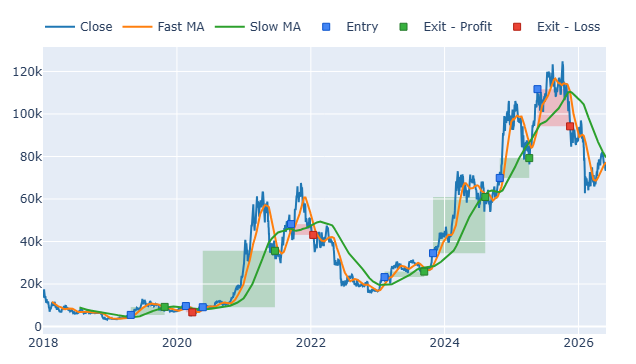

In [3]:
fig = price.vbt.plot(trace_kwargs=dict(name='Close'))
fast_ma.ma.vbt.plot(trace_kwargs=dict(name='Fast MA'), fig=fig)
slow_ma.ma.vbt.plot(trace_kwargs=dict(name='Slow MA'), fig=fig)
pf.positions.plot(close_trace_kwargs=dict(visible=False), fig=fig).show()

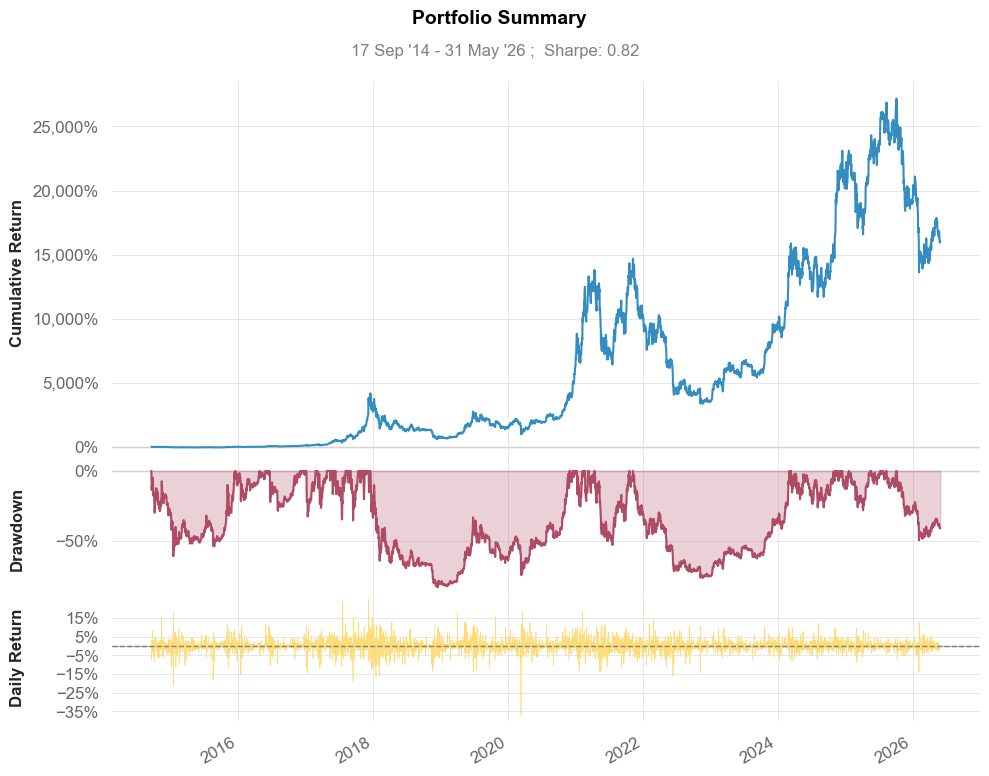

In [4]:
price = vbt.YFData.download('BTC-USD').get('Close')
returns = price.vbt.to_returns()
returns.vbt.returns.qs.plot_snapshot()

In [9]:
from datetime import datetime, timedelta
index = [datetime(2020, 1, 1) + timedelta(days=i) for i in range(7)]
mask = pd.Series([False, True, True, True, False, True, False], index=index)
mask.vbt.signals(freq='d').stats()

Start                             2020-01-01 00:00:00
End                               2020-01-07 00:00:00
Period                                7 days 00:00:00
Total                                               4
Rate [%]                                    57.142857
First Index                       2020-01-02 00:00:00
Last Index                        2020-01-06 00:00:00
Norm Avg Index [-1, 1]                      -0.083333
Distance: Min                         1 days 00:00:00
Distance: Max                         2 days 00:00:00
Distance: Mean                        1 days 08:00:00
Distance: Std               0 days 13:51:23.063257983
Total Partitions                                    2
Partition Rate [%]                               50.0
Partition Length: Min                 1 days 00:00:00
Partition Length: Max                 3 days 00:00:00
Partition Length: Mean                2 days 00:00:00
Partition Length: Std       1 days 09:56:28.051789035
Partition Distance: Min     

In [10]:
>>> price = vbt.YFData.download('BTC-USD').get('Close')
>>> slippage = np.random.uniform(0, 0.005, size=price.shape[0])
>>> logs = vbt.Portfolio.from_random_signals(price, n=5, slippage=slippage, log=True).logs

>>> req_price_ma = logs.map_field('req_price')
>>> res_price_ma = logs.map_field('res_price')
>>> slippage_ma = (res_price_ma - req_price_ma) / req_price_ma
>>> slippage_ma = slippage_ma.replace(arr=np.abs(slippage_ma.values))
>>> top_slippage_pd = slippage_ma.top_n(5).to_pd()
>>> top_slippage_pd[~top_slippage_pd.isnull()]


Date
2016-10-17 00:00:00+00:00    0.004547
2016-12-27 00:00:00+00:00    0.000821
2019-08-11 00:00:00+00:00    0.004811
2021-11-18 00:00:00+00:00    0.003609
2024-01-23 00:00:00+00:00    0.000359
dtype: float64

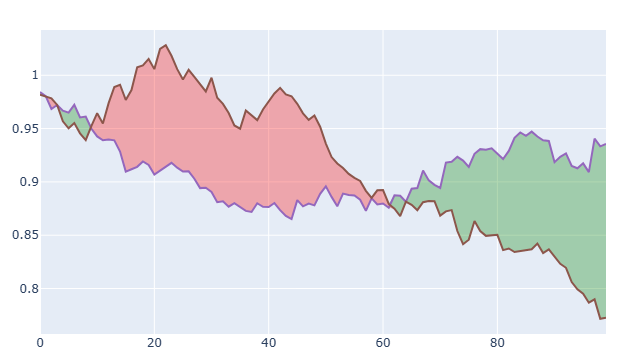

In [11]:
>>> sr1 = pd.Series(np.cumprod(np.random.normal(0, 0.01, 100) + 1))
>>> sr2 = pd.Series(np.cumprod(np.random.normal(0, 0.01, 100) + 1))
>>> sr1.vbt.plot_against(sr2).show()

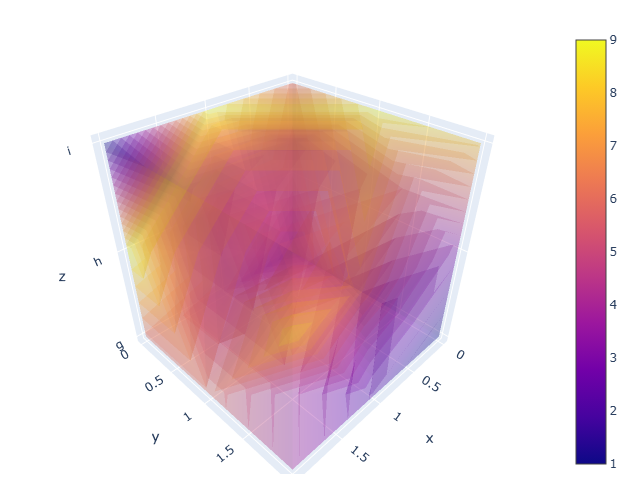

In [12]:
>>> volume_widget = vbt.plotting.Volume(
...     data=np.random.randint(1, 10, size=(3, 3, 3)),
...     x_labels=['a', 'b', 'c'],
...     y_labels=['d', 'e', 'f'],
...     z_labels=['g', 'h', 'i']
... )
>>> volume_widget.fig.show()

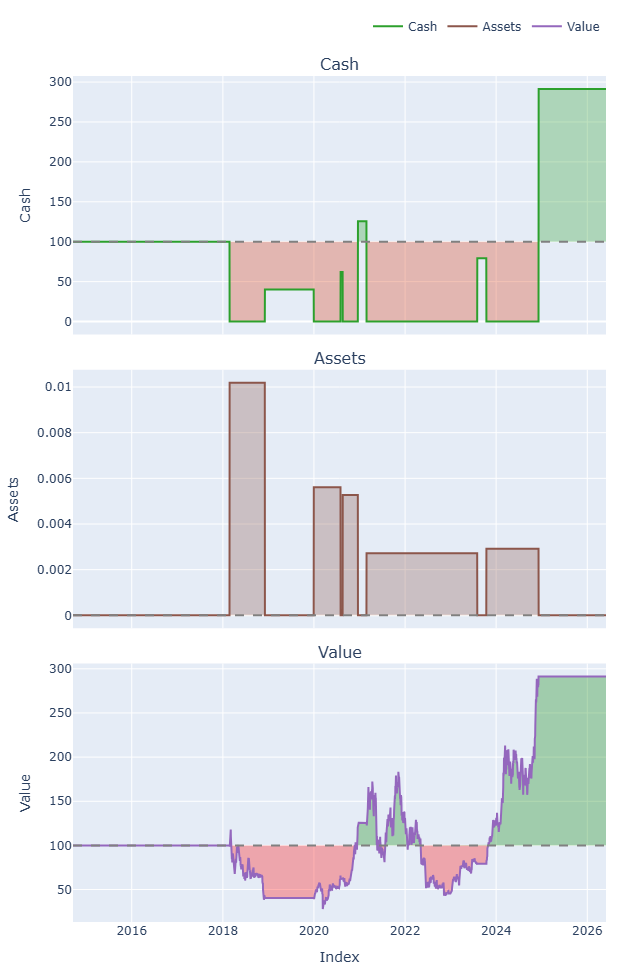

In [13]:
>>> price = vbt.YFData.download('BTC-USD').get('Close')
>>> pf = vbt.Portfolio.from_random_signals(price, n=5)
>>> pf.plot(subplots=['cash', 'assets', 'value']).show()

In [ ]:
>>> from vectorbt.utils.datetime_ import datetime_to_ms, to_tzaware_datetime, get_utc_tz
>>> from IPython.display import SVG, display, clear_output
import ccxt
>>> exchange = ccxt.binance()

>>> def job_func():
...     since = datetime_to_ms(to_tzaware_datetime('10 seconds ago UTC', tz=get_utc_tz()))
...     trades = exchange.fetch_trades('BTC/USDT', since)
...     price = pd.Series({t['datetime']: t['price'] for t in trades})
...     svg = price.vbt.plot().to_image(format="svg")
...     clear_output()
...     display(SVG(svg))

>>> scheduler = vbt.ScheduleManager()
>>> scheduler.every(10, 'seconds').do(job_func)
>>> scheduler.start()


In [16]:
>>> import time
>>> start = time.time()

>>> class MyClass:
...     @vbt.cached_method
...     def get_elapsed(self):
...         return time.time() - start

>>> my_inst = MyClass()
>>> my_inst.get_elapsed()
0.00010895729064941406

>>> my_inst.get_elapsed()
0.00010895729064941406

>>> get_elapsed_cond = vbt.CacheCondition(instance=my_inst, func='get_elapsed')
>>> vbt.settings.caching['blacklist'].append(get_elapsed_cond)
>>> my_inst.get_elapsed()
0.01081395149230957

0.01081395149230957

In [17]:
>>> price = vbt.YFData.download('BTC-USD').get('Close')
>>> pf = vbt.Portfolio.from_random_signals(price, n=5)
>>> pf.save('my_pf.pkl')

>>> pf = vbt.Portfolio.load('my_pf.pkl')
>>> pf.total_return()
5.96813681074424

5.96813681074424